In [85]:
import kagglehub

path = kagglehub.dataset_download("cameronseamons/electronic-sales-sep2023-sep2024")

print("Path to dataset files:", path)

Path to dataset files: /Users/vddmit/.cache/kagglehub/datasets/cameronseamons/electronic-sales-sep2023-sep2024/versions/5


**Задание 1**

In [119]:
import pandas as pd
import os

df_1 = pd.read_csv(os.path.join(path, "Electronic_sales_Sep2023-Sep2024.csv"))

df_1

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,NaN,0.00
19996,19996,27,Female,Yes,Laptop,LTP123,4,Cancelled,Credit Card,2697.28,674.32,4,2024-07-18,Standard,NaN,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Impulse Item, Extended Warranty, Accessory",198.98
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Extended Warranty, Accessory",101.34


In [87]:
def get_preferred_payment(series):
    counts = series.dropna().value_counts()
    if counts.empty:
        return None
    top = counts[counts == counts.max()].index
    return min(top)


df_clean = df_1.fillna({"Total Price": 0, "Add-on Total": 0})

result = (
    df_clean
    .groupby("Customer ID")
    .agg(
        preferred_payment=("Payment Method", get_preferred_payment),
        total_spent=("Total Price", "sum"),
        addons_spent=("Add-on Total", "sum"),  # нет доп. услуг -> 0
        orders_count=("Customer ID", "size"),  # одна строка = один заказ
    )
    .reset_index()
    .rename(columns={"Customer ID": "customer_id"})
    .sort_values("total_spent", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

result

,customer_id,preferred_payment,total_spent,addons_spent,orders_count
0,16357,Bank Transfer,34563.70,495.19,7
1,16863,PayPal,33035.92,486.17,5
2,13813,Credit Card,31830.16,268.64,5
3,11476,PayPal,31077.61,301.59,5
4,12276,Bank Transfer,30961.18,329.07,6
5,13635,Credit Card,30260.36,480.73,5
6,12749,Credit Card,29394.56,619.43,5
7,15399,PayPal,29084.88,305.39,3
8,12319,Bank Transfer,27352.32,226.38,3
9,19996,Bank Transfer,27296.78,432.12,6


**Задание 2**


In [121]:
import pandas as pd


def clean(df: pd.DataFrame) -> pd.DataFrame:
    """Очистка данных. Что фильтруем:
    - Purchase Date приводим к datetime; некорректные даты -> NaT -> удаляем;
    - удаляем строки с пропусками в ключевых колонках (покупатель, дата,
      метод оплаты, суммы, цена, количество);
    - пропуски в Add-on Total заполняем 0 (нет доп. услуг);
      Add-ons Purchased не трогаем: пусто = доп. услуг не было;
    - удаляем аномалии: цена и количество <= 0, Total Price <= 0,
      отрицательный Add-on Total. Нулевые и отрицательные заказы
      не попадают в доход.
    """
    df = df.copy()
    n0 = len(df)

    df["Purchase Date"] = pd.to_datetime(df["Purchase Date"], errors="coerce")

    key_cols = ["Customer ID", "Purchase Date", "Payment Method",
                "Total Price", "Unit Price", "Quantity"]
    df = df.dropna(subset=key_cols)
    df["Add-on Total"] = df["Add-on Total"].fillna(0)
    n1 = len(df)

    df = df[
        (df["Unit Price"] > 0)
        & (df["Quantity"] > 0)
        & (df["Total Price"] > 0)
        & (df["Add-on Total"] >= 0)
        ]
    n2 = len(df)

    print(f"Удалено из-за пропусков/некорректных дат: {n0 - n1}")
    print(f"Удалено из-за аномалий: {n1 - n2}")
    print(f"Осталось строк: {n2} из {n0}")
    return df


def _revenue_by(df: pd.DataFrame, col: str, label: str) -> pd.DataFrame:
    """Доход (Total Price) в разрезе колонки col, по убыванию."""
    return (
        df.groupby(col)["Total Price"]
        .sum()
        .sort_values(ascending=False)
        .rename_axis(label)
        .reset_index(name="revenue")
    )


def _addons_by_period(df: pd.DataFrame, freq: str, label: str) -> pd.DataFrame:
    """Доход с доп. услуг по периодам.
    Зафиксированное поведение: выводим ВСЕ периоды от первого до последнего;
    период без доп. услуг (или вовсе без заказов) -> строка с 0.
    """
    if df.empty:
        return pd.DataFrame(columns=[label, "addons_revenue"])

    periods = df["Purchase Date"].dt.to_period(freq)
    s = df.groupby(periods)["Add-on Total"].sum()
    full_range = pd.period_range(s.index.min(), s.index.max(), freq=freq)
    return (
        s.reindex(full_range, fill_value=0)
        .rename_axis(label)
        .reset_index(name="addons_revenue")
    )


def _cohorts(df: pd.DataFrame, max_offset: int = 3) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Когортный анализ. Когорта = месяц первого заказа покупателя.
    Возвращает две матрицы (строки - когорта, столбцы - месяц жизни 0..3):
    выручку и число уникальных покупателей.
    NaN = в этом месяце жизни у когорты нет заказов или месяц ещё не наблюдался
    (например, у поздних когорт данные заканчиваются раньше месяца 3).
    """
    offsets = list(range(max_offset + 1))
    if df.empty:
        empty = pd.DataFrame(columns=offsets).rename_axis("cohort")
        return empty, empty.copy()

    df_c = df.copy()
    df_c["order_month"] = df_c["Purchase Date"].dt.to_period("M")
    df_c["cohort"] = df_c.groupby("Customer ID")["order_month"].transform("min")
    df_c["month_offset"] = (
            (df_c["order_month"].dt.year - df_c["cohort"].dt.year) * 12
            + (df_c["order_month"].dt.month - df_c["cohort"].dt.month)
    )
    df_c = df_c[df_c["month_offset"].between(0, max_offset)]

    stats = df_c.groupby(["cohort", "month_offset"]).agg(
        revenue=("Total Price", "sum"),
        customers=("Customer ID", "nunique"),
    )

    # reindex гарантирует наличие всех столбцов 0..3, даже если какого-то нет в данных
    revenue = stats["revenue"].unstack().reindex(columns=offsets)
    customers = stats["customers"].unstack().reindex(columns=offsets)
    return revenue, customers


def build_metrics(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """Все метрики. Доход = Total Price (после clean только заказы с суммой > 0)."""
    cohort_revenue, cohort_customers = _cohorts(df)
    return {
        "revenue_by_shipping": _revenue_by(df, "Shipping Type", "shipping_method"),
        "revenue_by_product_type": _revenue_by(df, "Product Type", "product_type"),
        "addons_by_month": _addons_by_period(df, "M", "month"),
        "addons_by_quarter": _addons_by_period(df, "Q", "quarter"),
        "cohort_revenue": cohort_revenue,
        "cohort_customers": cohort_customers,
    }


df_2 = clean(df_1)
metrics = build_metrics(df_2)

metrics["cohort_customers"]

Удалено из-за пропусков/некорректных дат: 0
Удалено из-за аномалий: 0
Осталось строк: 20000 из 20000


month_offset,0,1,2,3
cohort,,,,
2023-09,185.0,19.0,19.0,18.0
2023-10,852.0,61.0,77.0,72.0
2023-11,686.0,54.0,63.0,47.0
2023-12,614.0,54.0,45.0,52.0
2024-01,1722.0,163.0,189.0,176.0
2024-02,1386.0,130.0,149.0,155.0
2024-03,1330.0,147.0,145.0,149.0
2024-04,1170.0,120.0,132.0,123.0
2024-05,1097.0,106.0,129.0,104.0


Matplotlib is building the font cache; this may take a moment.


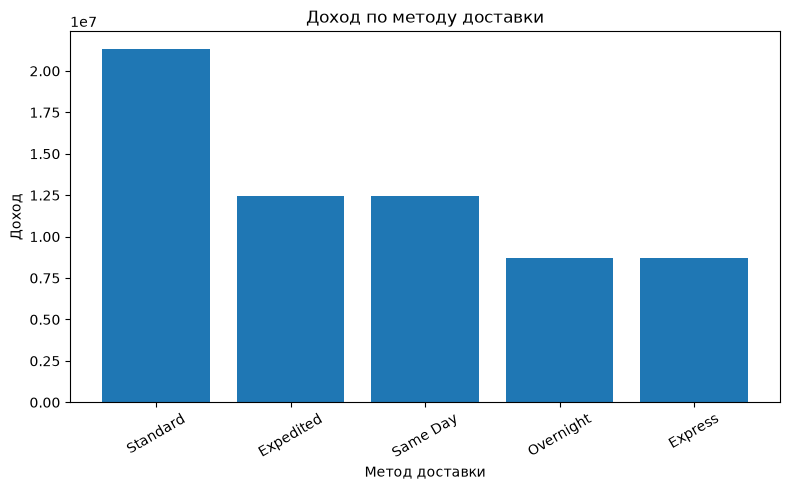

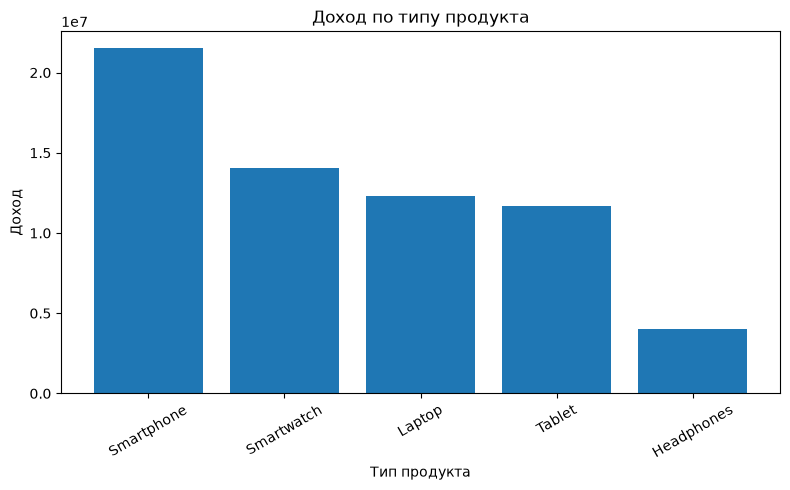

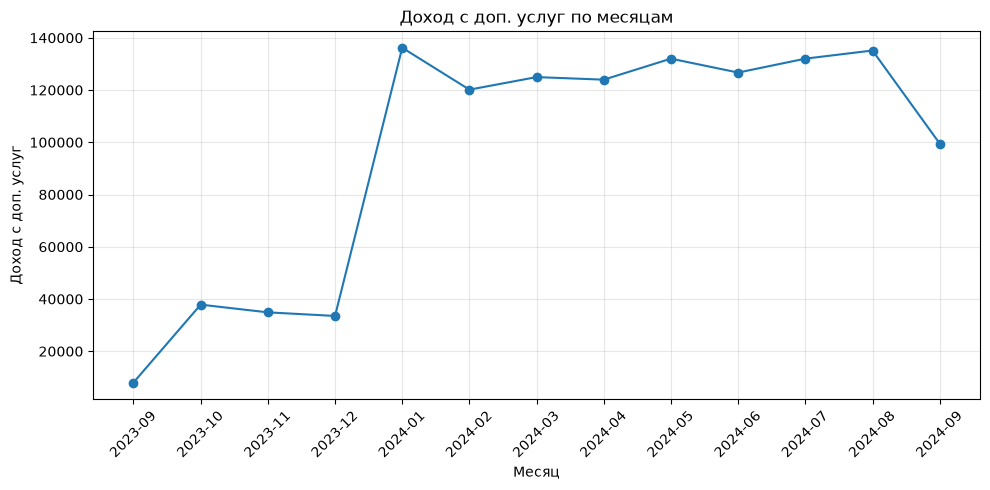

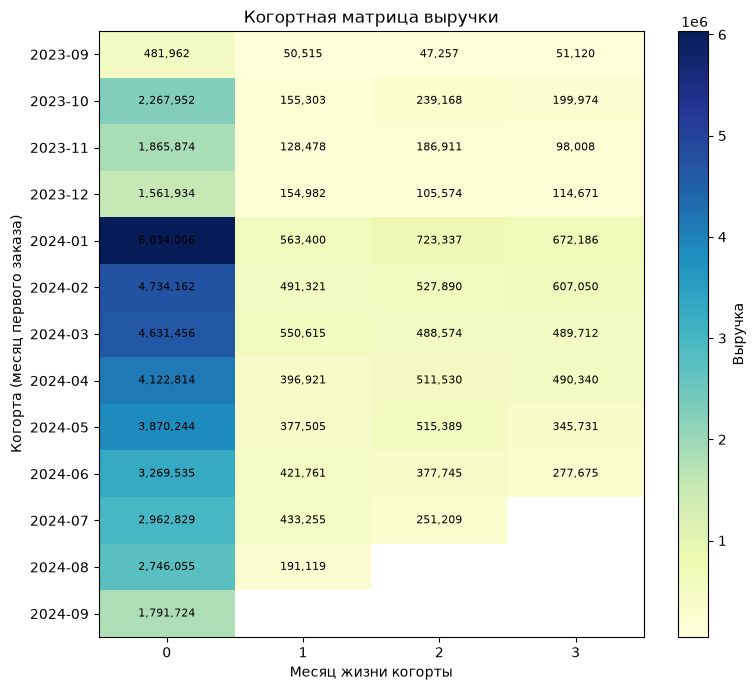

In [122]:
import matplotlib.pyp2lot as plt
import numpy as np


def plot_bar(df: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(df[x].astype(str), df[y])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    return fig, ax


def plot_addons_line(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df["month"].astype(str), df["addons_revenue"], marker="o")
    ax.set_title("Доход с доп. услуг по месяцам")
    ax.set_xlabel("Месяц")
    ax.set_ylabel("Доход с доп. услуг")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    return fig, ax


def plot_cohort_heatmap(matrix: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 7))
    values = matrix.to_numpy(dtype=float)
    im = ax.imshow(values, aspect="auto", cmap="YlGnBu")

    ax.set_xticks(range(matrix.shape[1]))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_yticklabels(matrix.index.astype(str))

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if not np.isnan(values[i, j]):
                ax.text(j, i, f"{values[i, j]:,.0f}", ha="center", va="center", fontsize=8)

    ax.set_title("Когортная матрица выручки")
    ax.set_xlabel("Месяц жизни когорты")
    ax.set_ylabel("Когорта (месяц первого заказа)")
    fig.colorbar(im, ax=ax, label="Выручка")
    fig.tight_layout()
    return fig, ax


def plot_all(metrics: dict[str, pd.DataFrame]):
    if metrics["revenue_by_shipping"].empty:
        print("Нет данных для графиков")
        return

    plot_bar(metrics["revenue_by_shipping"], "shipping_method", "revenue",
             "Доход по методу доставки", "Метод доставки", "Доход")
    plot_bar(metrics["revenue_by_product_type"], "product_type", "revenue",
             "Доход по типу продукта", "Тип продукта", "Доход")
    plot_addons_line(metrics["addons_by_month"])
    plot_cohort_heatmap(metrics["cohort_revenue"])
    plt.show()


plot_all(metrics)